# 📝 Instrucciones: Campaña de Marketing Bancario

## 1. Comprensión empresarial
Los **depósitos a largo plazo** permiten a los bancos retener capital durante un período específico, facilitando la inversión de estos fondos en otros activos financieros. 

Actualmente, las campañas de marketing para este producto se realizan mediante **llamadas telefónicas**. Si un usuario no está disponible, se programa una nueva llamada para un momento posterior.

## 2. Descripción del problema
Un banco portugués ha detectado una disminución en sus ingresos. Para revertir esta tendencia, necesitan identificar a los clientes existentes con **mayor probabilidad de contratar un depósito a largo plazo**.

**Objetivo:** Crear un algoritmo de clasificación que prediga la suscripción del cliente para optimizar los esfuerzos de marketing, ahorrando tiempo y recursos.

---

## 3. Pasos del Proyecto

### Paso 1: Carga del conjunto de datos
El archivo se encuentra en el repositorio como `bank-marketing-campaign-data.csv`. Puedes cargarlo directamente desde este enlace:

> 🔗 [Descargar Dataset](https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv)

#### Diccionario de Datos:
| Variable | Descripción | Tipo |
| :--- | :--- | :--- |
| **age** | Edad del cliente | Numérico |
| **job** | Tipo de trabajo | Categórico |
| **marital** | Estado civil | Categórico |
| **education** | Nivel de educación | Categórico |
| **default** | ¿Tiene crédito actualmente? | Categórico |
| **housing** | ¿Tiene un préstamo de vivienda? | Categórico |
| **loan** | ¿Tiene un préstamo personal? | Categórico |
| **contact** | Tipo de comunicación de contacto | Categórico |
| **month** | Último mes de contacto | Categórico |
| **day_of_week** | Último día de contacto | Categórico |
| **duration** | Duración del último contacto (segundos) | Numérico |
| **campaign** | Número de contactos en esta campaña | Numérico |
| **pdays** | Días desde el último contacto en campaña previa | Numérico |
| **previous** | Número de contactos previos a esta campaña | Numérico |
| **poutcome** | Resultado de la campaña de marketing anterior | Categórico |
| **emp.var.rate** | Tasa de variación del empleo (trimestral) | Numérico |
| **cons.price.idx**| Índice de precios al consumidor (mensual) | Numérico |
| **cons.conf.idx** | Índice de confianza del consumidor (mensual) | Numérico |
| **euribor3m** | Tasa EURIBOR 3 meses (diario) | Numérico |
| **nr.employed** | Número de empleados (trimestral) | Numérico |
| **y (TARGET)** | ¿El cliente contrata el depósito? | **Categórico** |

### Paso 2: Análisis Exploratorio de Datos (EDA)
Es fundamental realizar un EDA completo para filtrar variables irrelevantes.
* Adapta el Notebook de ejemplo a este caso de uso.
* **Importante:** Divide el conjunto de datos en los sets de **entrenamiento (train)** y **prueba (test)**.

### Paso 3: Construcción del modelo
Construye un modelo de **Regresión Logística**. 
* En esta etapa, utiliza la configuración por defecto de la librería para establecer una línea base.

### Paso 4: Optimización
Si los resultados iniciales no son satisfactorios, aplica técnicas de optimización de hiperparámetros o ingeniería de variables para mejorar la precisión del modelo.

In [1]:
#Importo todas las librerias que voy a necesitar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# OJO!!!! las funciones create_factor_transf_and_json, prepare_test_data y train_print_model son de creacion personal estan en utils
# (archivo que ya existia en este repositorio).
from utils import create_factor_transf_and_json, prepare_test_data, train_print_model

In [2]:
# Cargamos el dataset usamos el delimitador ";"
total_data = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv', delimiter = ";")
# Intentamos convertir cualquier nombre de columna a snake_case
total_data.columns = total_data.columns.str.replace(r'[^\w]', '_', regex=True)
total_data.columns = total_data.columns.str.replace(r'_+', '_', regex=True).str.strip('_')
#imprimimos los primeros 5
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en total_data que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(total_data.dtypes)

Numero De Filas en 'total_data': 41188


str        11
int64       5
float64     5
Name: count, dtype: int64

In [4]:
#Obtenemos Informacion Sobre Los Tipos De Datos Y Valores No Nulos
print("------------------PORCENTAJE DE VALORES NULOS DEL DATAFRAME---------------------\n")
#Obtenemos que columnas tienen valores nulos y el que porcentage respectivamente
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending = False)

------------------PORCENTAJE DE VALORES NULOS DEL DATAFRAME---------------------



age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp_var_rate      0.0
cons_price_idx    0.0
cons_conf_idx     0.0
euribor3m         0.0
nr_employed       0.0
y                 0.0
dtype: float64

# Conclusiones (Hasta Ahora):
* Tenemos un dataframe total_data con 21 columnas y 41188  filas
* 5 columnas son int64,5 float64 y 11 str. 
* Ninguna de esas columnas tienen valores nulos.

In [5]:
# En el ejercicio anterior graficamos los valores nulos pero en este caso no nos encontramos con nulos en ninguna de las variables
# Revisar Los Posibles Datos Categoricos
total_data.select_dtypes(include = ['str']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

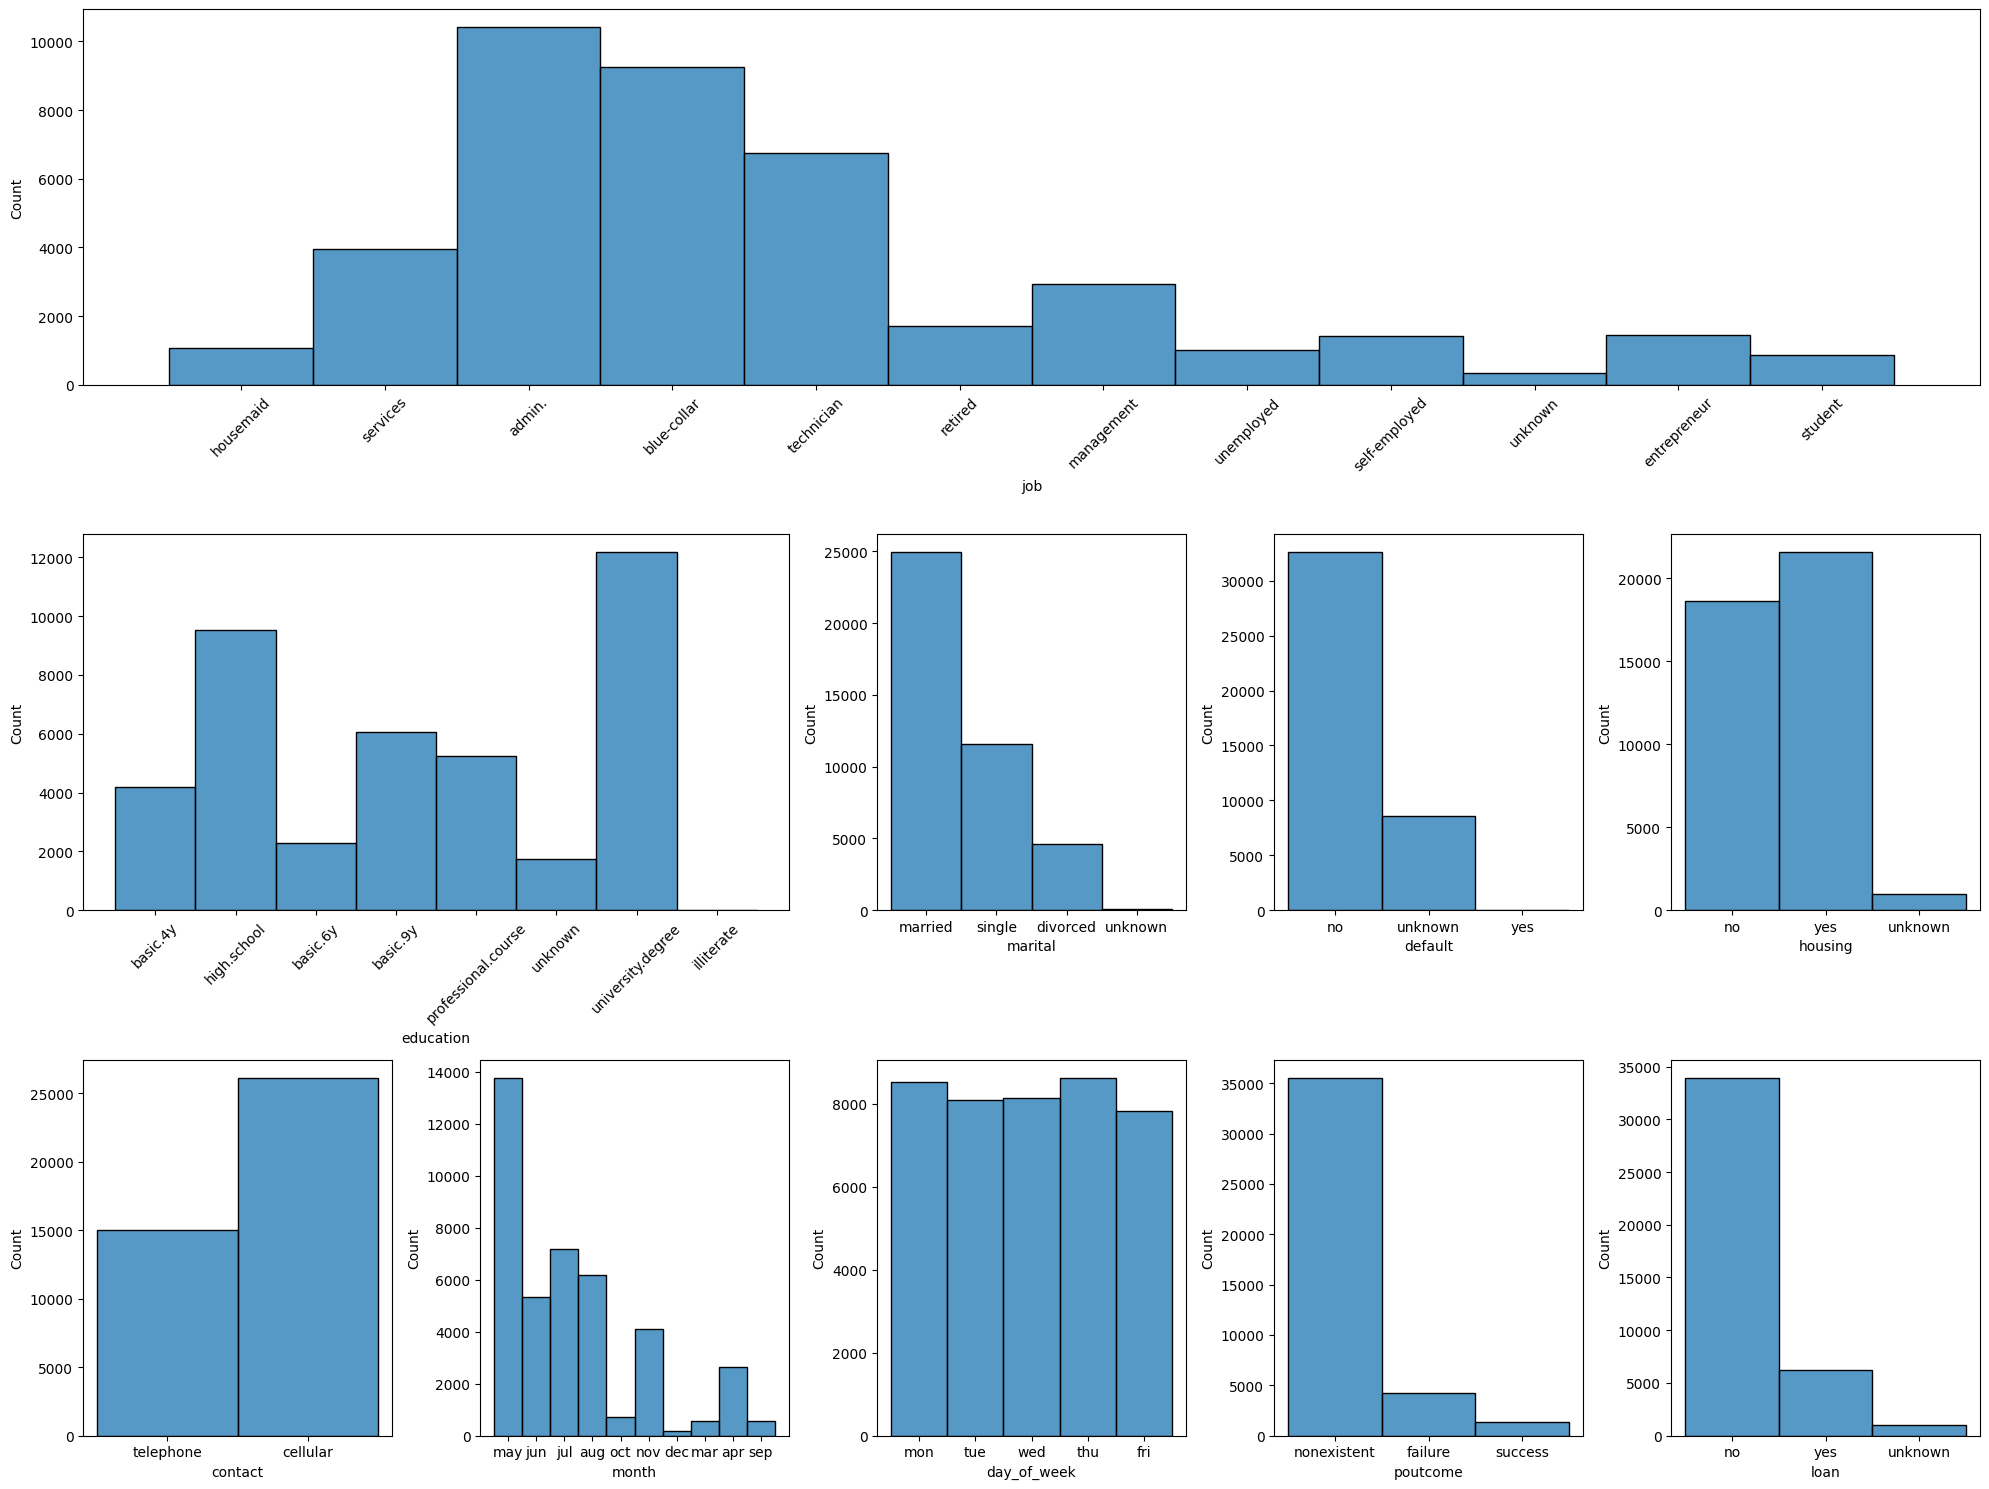

In [6]:
#Creamos Un Histograma Multiple
fig = plt.figure(figsize = (20, 15))
#Creamos un grid porque necesitaremos hacer unos ajustes de tamaños en algunos graficos, el grid va a ser de 3x5
axis = gridspec.GridSpec(3, 5, figure = fig)
#le decimos al primer grid que ocupe toda la fila
axis0 = fig.add_subplot(axis[0, :])
sns.histplot(data = total_data, x = 'job', ax = axis0)
#y rotamos un poco los labels
axis0.tick_params(axis = 'x', rotation = 45)
#el segundo grafico va a ocupar 2 espacios
axis1 = fig.add_subplot(axis[1, 0:2]); sns.histplot(data = total_data, x = 'education', ax = axis1)
axis1.tick_params(axis='x', rotation = 45)
#el resto solo uno
axis2 = fig.add_subplot(axis[1, 2]); sns.histplot(data = total_data, x='marital', ax = axis2)
axis3 = fig.add_subplot(axis[1, 3]); sns.histplot(data = total_data, x='default', ax = axis3)
axis4 = fig.add_subplot(axis[1, 4]); sns.histplot(data = total_data, x='housing', ax = axis4)
axis5 = fig.add_subplot(axis[2, 4]); sns.histplot(data = total_data, x='loan', ax = axis5)
axis6 = fig.add_subplot(axis[2, 0]); sns.histplot(data = total_data, x='contact', ax = axis6)
axis7 = fig.add_subplot(axis[2, 1]); sns.histplot(data = total_data, x='month', ax = axis7)
axis8 = fig.add_subplot(axis[2, 2]); sns.histplot(data = total_data, x='day_of_week', ax = axis8)
axis9 = fig.add_subplot(axis[2, 3]); sns.histplot(data = total_data, x='poutcome', ax = axis9)

#Ajustar Layaut
plt.tight_layout()
#Mostramos El Plot
plt.show()

### Son Categorizables?:
#### Analisis e Interpretacion De Columnas(Variables):
| Variable | Descripción | Analisis |
| :--- | :--- | :--- |
| **`job`** | Tipo de trabajo | Puesto que en ciertos trabajos se manejan conceptos economicos puede servir para nuestro target, ademas el nivel adquisitivo ofrece mas seguridad a la hora de invertir.
| **`marital`** | Estado civil | Personas solteras suelen tener menos gastos, aunque esto varia si tiene hijos o no, igual son mas propensos a invertir. 
| **`education`** | Nivel de educación | Parecido al la variable job puede dar señales de conocimientos economicos y de inversion.
| **`default`** | ¿Tiene crédito actualmente? | Si usuario posee un credito, aunque use un servicio del banco, forma parte del "Dame dinero" y no del "Tomalo e inviertelo" pero el grafico demuestra que la gran mayoria no posee credito actualmente, y el resto se desconoce, se va a descartar esta columna porque no aporta info.
| **`housing`** | ¿Tiene un préstamo de vivienda? | Igual que el punto anterior pero aca si tenemos datos diversos por lo que lo tendremos en cuenta.
| **`loan`** | ¿Tiene un préstamo personal? | Igual que el punto anterior aunque disparejo en si posee prestamo o no por lo menos tenemos algunos valores en "yes".
| **`contact`** | Tipo de comunicación de contacto | Como vimos en el enunciado se suelen ofrecer estos servicios por llamadas puede ser por telefono o celular
| **`month`** | Último mes de contacto | Si un cliente respondio negativamente a el ultimo contacto, es mas posible que cambie de opinion mientras mas tiempo pase desde el ultimo contacto.
| **`day_of_week`** | Último día de contacto | Es menos especifico que la variable anterior y pueden solaparse, se puede crear una variable conjunta, el grafico muestra mucha paridad por lo que no nos aporta info relevante por si sola.
| **`poutcome`** | Resultado de la campaña de marketing anterior | Puede ser usable pero el grafico muestra una mayoria en noexistente, una parte en failiure y un muy minimo "success" que va con la problematica del target quizas haya informacion relevante en esos pocos success. 
| **`y` (TARGET)** | ¿El cliente contrata el depósito? | Es nuestro Target.
#### Variables Categorizables: 
* Atraves de Pandas Dummies por que todos los valores unicos tienen la misma importancia numerica, ademas para regresion logistica suele dar mejores resultados:
    * `job`
    * `marital`
    * `education`
    * `housing`
    * `loan`
    * `contact`
    * `month`
    * `poutcome`
    * `day_of_week`
* Atraves de Pandas Factorize porque solo son dos posibles valores, True o False:
    * `y`

## Rellenar Valores Unknown?:
    En este caso mas que valores erroneos, son desconocimiento de la informacion asi que voy a dejar "Unknown" en las columnas que las tienen como una categoria mas.

In [7]:
#Factorizamos las variables categoricas con la funcion "create_factor_transf_and_json" vamos a factorizar casi todo con pandas dummies para que el modelo no asuma
# que el "trabajo 2" es mayor que el "trabajo 1" con y_target uso un factorize normal.

#Columnas Dummies: label_encoder = "pdd"
create_factor_transf_and_json("job", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("marital", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("education", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("housing", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("loan", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("contact", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("month", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("poutcome", total_data, "BancoEjercicio2", label_encoder = "pdd")
create_factor_transf_and_json("day_of_week", total_data, "BancoEjercicio2", label_encoder = "pdd")
#Columnas Factorize:label_encoder = "pdf"
create_factor_transf_and_json("y", total_data, "BancoEjercicio2", label_encoder = "pdf")
total_data

Json guardado en: ../data/processed/factories/BancoEjercicio2\job_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\marital_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\education_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\housing_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\loan_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\contact_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\month_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\poutcome_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\day_of_week_dummies_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\y_factory_rules.json


,age,default,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,...,month_sep_dummy,poutcome_failure_dummy,poutcome_nonexistent_dummy,poutcome_success_dummy,day_of_week_fri_dummy,day_of_week_mon_dummy,day_of_week_thu_dummy,day_of_week_tue_dummy,day_of_week_wed_dummy,y_factor
0,56,no,261,1,999,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,True,False,False,False,0
1,57,unknown,149,1,999,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,True,False,False,False,0
2,37,no,226,1,999,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,True,False,False,False,0
3,40,no,151,1,999,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,True,False,False,False,0
4,56,no,307,1,999,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,True,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,no,334,1,999,0,-1.1,94.767,-50.8,1.028,...,False,False,True,False,True,False,False,False,False,1
41184,46,no,383,1,999,0,-1.1,94.767,-50.8,1.028,...,False,False,True,False,True,False,False,False,False,0
41185,56,no,189,2,999,0,-1.1,94.767,-50.8,1.028,...,False,False,True,False,True,False,False,False,False,0
41186,44,no,442,1,999,0,-1.1,94.767,-50.8,1.028,...,False,False,True,False,True,False,False,False,False,1


In [8]:
# Ahora seleccionamos variables numericas
total_data.select_dtypes(include = ['int', 'float']).columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
       'y_factor'],
      dtype='str')

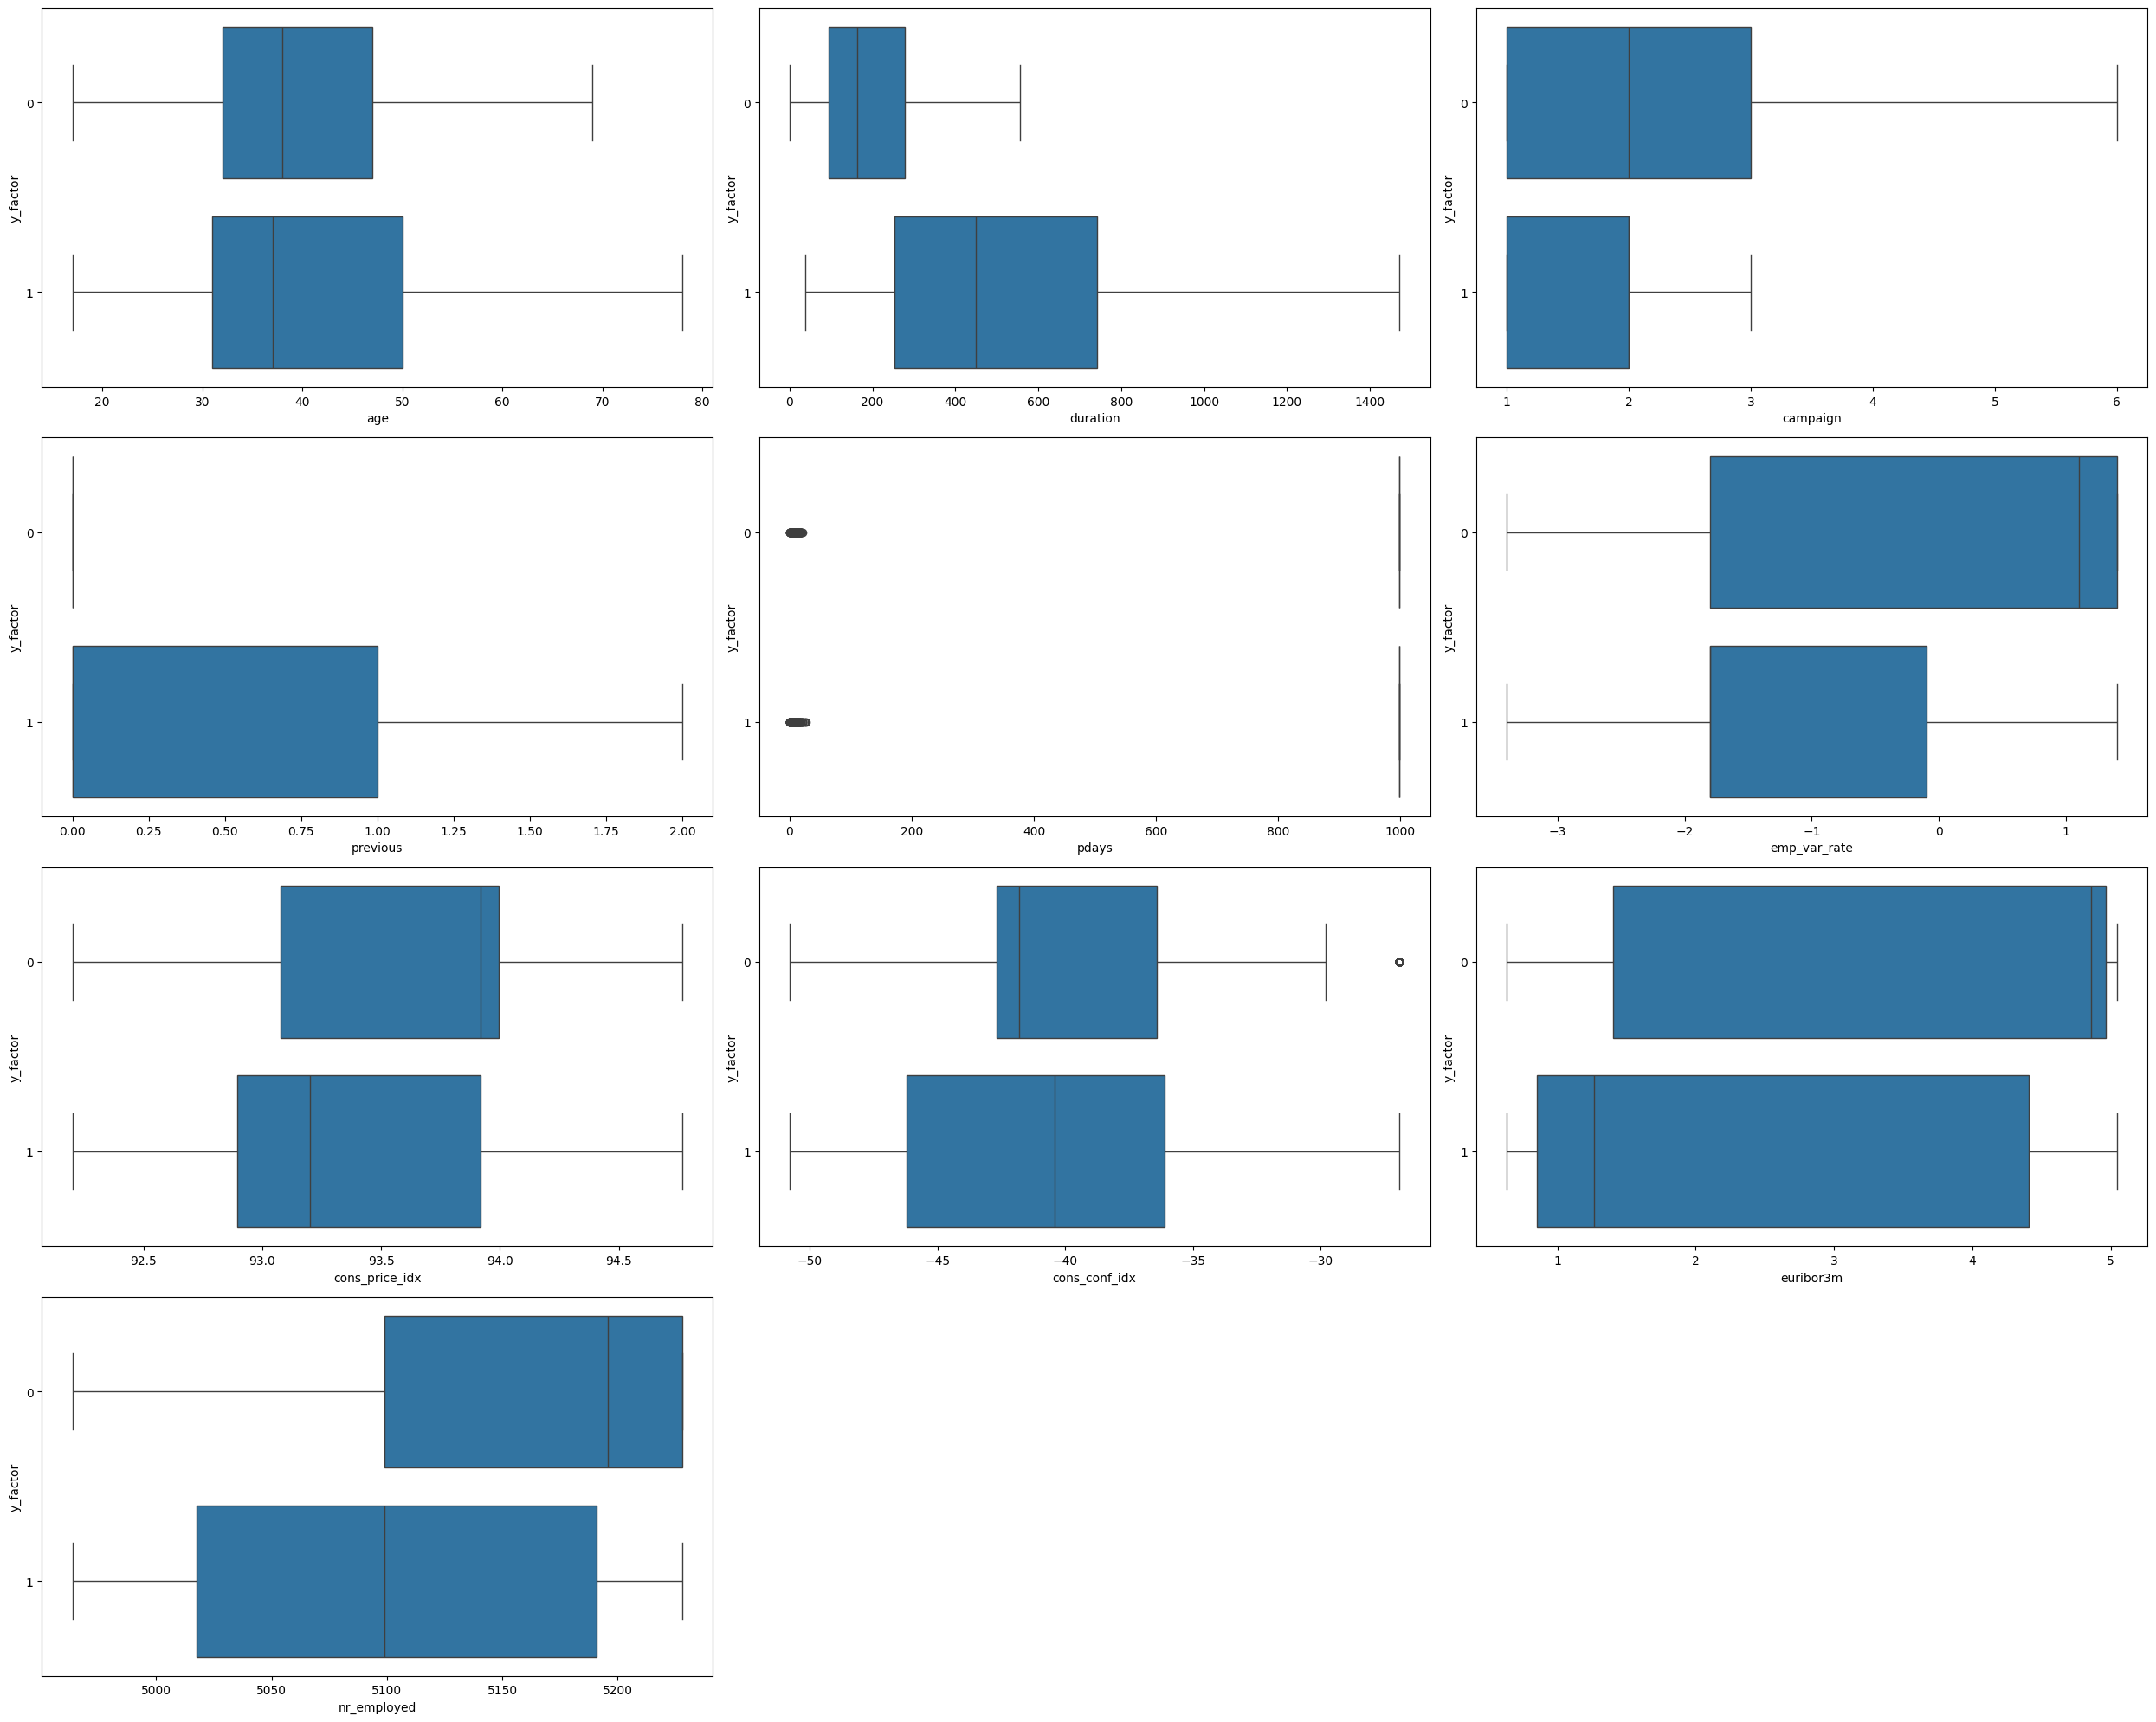

In [9]:
#Vamos a hacer un multigrafico de caja y bigotes para hechar un primer vistazo a las variables numericas
fig = plt.figure(figsize=(25, 20))

# Creamos el grid de 3x5
axis = gridspec.GridSpec(4, 3, figure = fig)

# showfliers=False para ocultar los outliers, dado que es dificil interpretar las cajas con estos al menos en los 4 primeros.
axis0 = fig.add_subplot(axis[0, 0]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'age', ax = axis0, showfliers=False)
axis1 = fig.add_subplot(axis[0, 1]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'duration', ax = axis1, showfliers=False)
axis2 = fig.add_subplot(axis[0, 2]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'campaign', ax = axis2, showfliers=False)
axis4 = fig.add_subplot(axis[1, 0]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'previous', ax = axis4, showfliers=False)
axis3 = fig.add_subplot(axis[1, 1]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'pdays', ax = axis3)
axis5 = fig.add_subplot(axis[1, 2]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'emp_var_rate', ax = axis5)
axis6 = fig.add_subplot(axis[2, 0]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'cons_price_idx', ax = axis6)
axis7 = fig.add_subplot(axis[2, 1]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'cons_conf_idx', ax = axis7)
axis8 = fig.add_subplot(axis[2, 2]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'euribor3m', ax = axis8)
axis9 = fig.add_subplot(axis[3, 0]); sns.boxplot(data = total_data, orient="h" ,y = 'y_factor', x = 'nr_employed', ax = axis9)

# Ajustar Layout para que no se solapen los titulos
plt.tight_layout()
plt.show()

#### Analisis e interpretacion de variables(numericas):
| Variable | Descripción | Analisis |
| :--- | :--- | :--- |
| **`age`** | Edad del cliente | Las Dos Cajas son muy parecidas pero el bigote de los que contrataron el servicio esta un poco mas alto, puede indicar que personas por encima de los 70 años son mas propensas a contratar el servicio |
| **`duration`** | Duración del último contacto (segundos) | Aca vemos que la segunda caja casi supera a la primera, indicante que mientras mmas dure la llamada es mas la persona es mas propensa a contratar el servicio, Las otras probablemente colgaron o dirjeron un rotundo "No, Gracias"  |
| **`campaign`** | Número de contactos en esta campaña | La primera Caja es significativamente mas alta que la segunda, se puede concluir aca que por mas llamadas que se hagan a un cliente no cambiaran de opinion la mayoria de las veces. |
| **`pdays`** | Días desde el último contacto en campaña previa | podemos observar que ni se ven las cajas casi todos los valores estan cerca de 1000 casi que diciendonos que no ha habido contacto(podemos decir esos valores en 1000 representan nada en lugar de dias), aca los outliers pueden significar algo. |
| **`previous`** | Número de contactos previos a esta campaña | podemos observar que los datos de la primera caja estan comprimidos o aplastados haciendo que la mayoria de los datos esten aca, podemos decir que la mayoria son clientes nuevos, pero hay unos pocos que representan la segunda caja e indican que puede haber fidelidad de clientes que hayan sido contactado antes. |
| **`emp_var_rate`** | Tasa de variación del empleo (trimestral) | Un variable con resultados extraños, mientras cuando las variacion de empleo en positivo (es decir estables) no provocaron que los clientes contrataran, la variacion negativa de la segunda caja (la media que es -1.8 aprox) nos indica que mientras menos estable fue el empleo mas contrataciones hubo. |
| **`cons_price_idx`**| Índice de precios al consumidor (mensual) | esta variable ya es un poco mas consistente representa la inflacion, mientras que la primera caja hubo in indice alto(cosas mas caras) no hubo contrato, por otra parte la segunda caja que tiene una media mas baja, indica que si hubo menos imflacion(cosas mas baratas) las personas fueron mas propensas a depositar. |
| **`cons_conf_idx`** | Índice de confianza del consumidor (mensual) | ambas cajas estan en negativo y sus medias se paracen, indica que aunque algunos contrataron y otros no, ambos estan pesimistas pero la segunda caja esta ligeramente por arriba, haciendo que si eres menos pesimista seas mas propenso a contratar el servicio a largo plazo del banco. |
| **`euribor3m`** | Tasa EURIBOR 3 meses (diario) | El EURIBOR son los intereses que se pagan los bancos entre si, aunque no afecta directamente al cliente,indirectamente afecta a los intereses que les da el banco, pero en nuestro grafico la media de la primera caja 4.8 aprox es mas alta que la segunda 1.3 aprox es un poco contradictorio pero puede tener que ver con la especulacion cuando hay intereses altos |
| **`nr_employed`** | Número de empleados (trimestral) | Otro punto extraño, cuando hubo mas empleabilidad hubieron menos adquisicion de servicios, puede indicar que el banco tiene mejor exito en las crisis, suele pasar con algunas empresas que aprovenchan las crisi como oportunidades |

In [10]:
#Transformar pdays para que los 999 no afecten nuestro modelo
def transform_pdays(x):
    if x != 999:
        return 0
    else:
        return 1
create_factor_transf_and_json("pdays", total_data, "BancoEjercicio2", "y_factor", transformation = True, transformation_func = transform_pdays)
#Eliminamos la coluna default que habiamos dicho antes que la ibamos a eliminar
total_data.drop(["default"],  axis = 1,  inplace = True)
total_data.head()

Json guardado en: ../data/processed/tranformations/BancoEjercicio2\pdays_transformation_rules.json


,age,duration,campaign,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_admin._dummy,...,poutcome_failure_dummy,poutcome_nonexistent_dummy,poutcome_success_dummy,day_of_week_fri_dummy,day_of_week_mon_dummy,day_of_week_thu_dummy,day_of_week_tue_dummy,day_of_week_wed_dummy,pdays_transf,y_factor
0,56,261,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,True,False,False,True,False,False,False,1,0
1,57,149,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,True,False,False,True,False,False,False,1,0
2,37,226,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,True,False,False,True,False,False,False,1,0
3,40,151,1,0,1.1,93.994,-36.4,4.857,5191.0,True,...,False,True,False,False,True,False,False,False,1,0
4,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,True,False,False,True,False,False,False,1,0


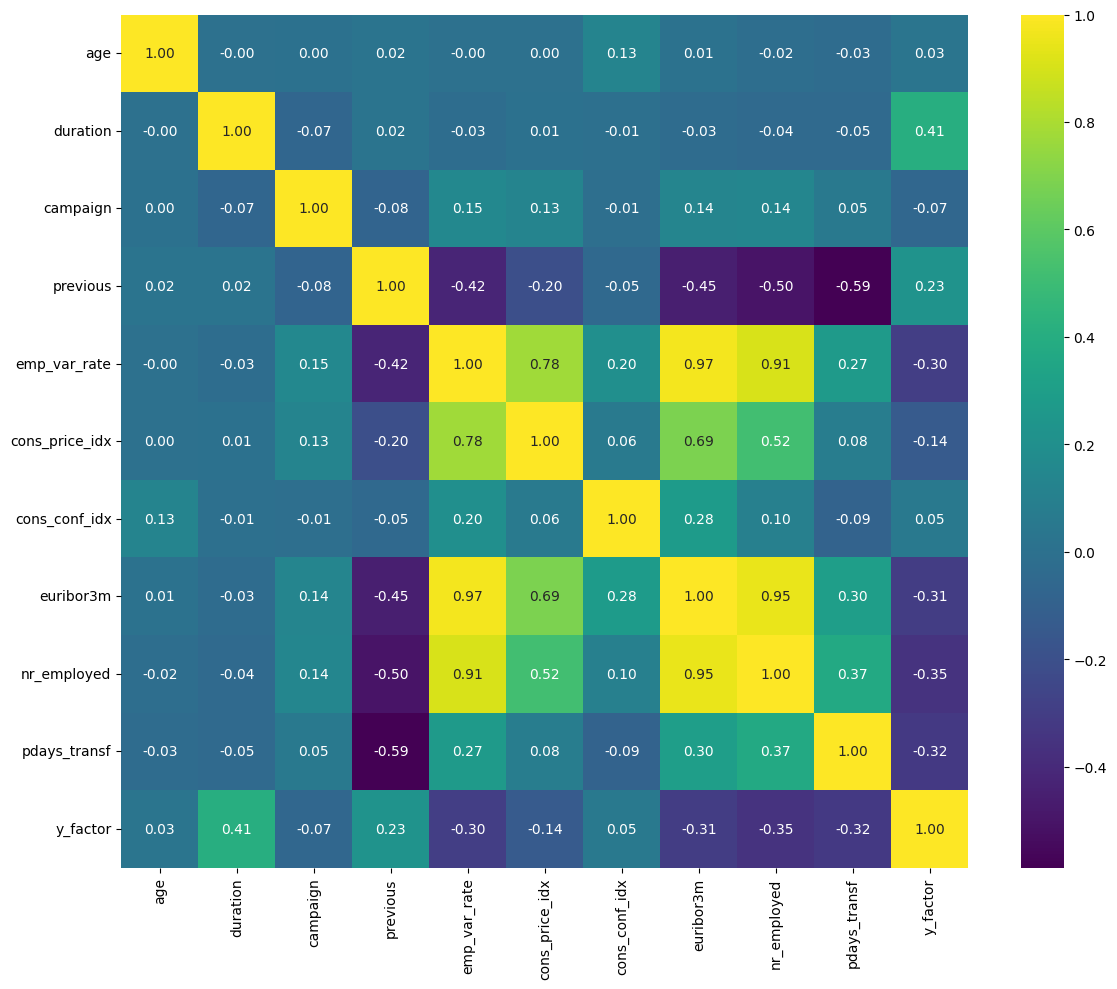

In [ ]:
#Graficamos en un heatmap para ver las correlaciones del resto de variables numericas
cols_num = total_data.select_dtypes(include = ['number']).columns
fig, ax = plt.subplots(figsize = (12,  10))
sns.heatmap(total_data[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis", ax = ax)
plt.tight_layout()
plt.show()

### Interpretacion del Heatmap
Es un grafico bastante extenso pero nos vamos a enfocar en las correlaciones de nuestro target **y_factor** buscaremos valores <= -0.10 y >= 0.10, ademas tomaremos valores >= 0.7 como redundantes:
* `Duration`: Nuestro mejor indicador 0.41 o casi, la descripcion oficial de este dataset, dice algo importante sobre la columna duration : "Este atributo afecta en gran medida al objetivo... sin embargo, la duracion no se conoce antes de realizar la llamada"
* `Previous`: Con un 0.23 lo vamos a dejar dado que en el grafico de cajas habia una minoria de clientes que usaron el servicio.
* `emp_var_rate`, `euribor3m` y `nr_employed`: poseen correlaciones parecidas -0.30,-0.31 y -0.35 respectivamente, pueden ser redundantes entre si, ya que las correlaciones entre ellos van desde 0.91 hasta 0.97. nos quedamos con nr.employed que es mas alto.
* `cons_price_idx`: Tiene un factor de -0.14 en el punto anterrior nos quedanmos con `nr_employed` y la correlacion con este es de 0.52, podria ser redundante pero no necesariamente asi que nos quedaremos con estos dos.
* `poutcome_factor`: con un 0.27 a primera vista tambien es un buen indicador pero la mayoria de sus datos son "inexistente", sin embargo al ser el resultado de una campaña anterior es una variable muy importante aunque nos de solo unos pocos datos de los que usaron el servicio.
* `contact_factor`: 0.15, no tan alto pero ya vimos si puede haber una tendencia, Lo dejamos para ver si el canal de comunicación influye en la tasa de éxito.
* `month_factor`: 0.19, tambien vimos que el tiempo del ultimo contacto influye asi que lo dejamos.
* `pdays_transf`: es alto - 0.32 y despues de transformarlo nos aseguramos que no confunda al modelo.

In [12]:
#Inicializamos una lista de columnas que seran de base para trabajar con una copia del dataframe
columns_list=list(total_data.columns)
#Eliminamos `emp_var_rate`, `euribor3m` 
columns_list.remove("emp_var_rate")
columns_list.remove("euribor3m")
df_model = total_data[columns_list].copy()

In [13]:
# ejecutamos la funcion prepare_test_data y guardamos los resultados en "ptd"
# en este caso ponemos stractify true porque nuestro target y = 1 que son muy pocos valores en relacion a y = 0.
ptd = prepare_test_data(df_model, "y_factor", "BancoEjercicio2", scaler_type = 1, stratify = True)
ptd.x_train_out.head()

,age,duration,campaign,previous,cons_price_idx,cons_conf_idx,nr_employed,job_admin._dummy,job_blue-collar_dummy,job_entrepreneur_dummy,...,month_sep_dummy,poutcome_failure_dummy,poutcome_nonexistent_dummy,poutcome_success_dummy,day_of_week_fri_dummy,day_of_week_mon_dummy,day_of_week_thu_dummy,day_of_week_tue_dummy,day_of_week_wed_dummy,pdays_transf
25611,0.863739,-0.120196,0.522981,-0.350127,-0.648967,-0.322269,0.398990,0,1,0,...,0,0,1,0,0,0,0,0,1,1
26010,-0.289722,-0.216732,-0.203688,1.653813,-0.648967,-0.322269,0.398990,0,0,1,...,0,1,0,0,0,0,0,0,1,1
40194,3.651268,3.436173,-0.567023,-0.350127,1.103451,0.045048,-2.420139,0,0,0,...,0,0,1,0,0,1,0,0,0,1
297,-0.385843,-0.533368,-0.203688,-0.350127,0.721890,0.887717,0.332723,1,0,0,...,0,0,1,0,0,1,0,0,0,1
36344,1.824956,0.424264,-0.203688,-0.350127,-1.058152,-0.062987,-1.252175,0,0,0,...,0,0,1,0,0,0,0,1,0,1


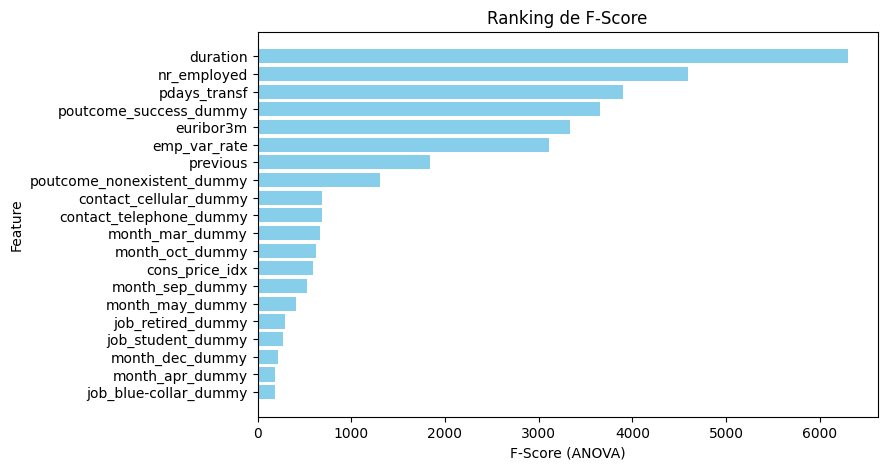

Ranking de variables por F-score:


,Feature,F-Score
0,duration,6303.936492
1,nr_employed,4591.467371
2,pdays_transf,3905.423695
3,poutcome_success_dummy,3652.949339
59,euribor3m,3334.921621
58,emp_var_rate,3110.163775
4,previous,1836.226549
5,poutcome_nonexistent_dummy,1303.962080
6,contact_cellular_dummy,690.157641
7,contact_telephone_dummy,690.157641


In [19]:
#vamos a tomar del collab el codigo para encontrar los F-scores y graficarlos  
pipe = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "median")),          # rellenamos con NaN con la mediana
    ("selector", SelectKBest(score_func = f_classif, k = 5))    # seleccionamos las 5 mejores variables
])
# Ajusto el pipeline antes de acceder a los scores
pipe.fit(ptd.x_train_out, ptd.y_train_out)
scores = pipe.named_steps["selector"].scores_
feature_scores = pd.DataFrame({
    "Feature": ptd.x_train_out.columns,
    "F-Score": scores
}).sort_values(by = "F-Score", ascending = False)

#Vamos a mostrar solo los primeros 30 ya que como tenemos muchas columnas dummies no se va a ver bien el grafico 
top_n = 20
selected_features = feature_scores.head(top_n)
#Grafico Barras Con La Imporancia De Cada Variable
plt.figure(figsize = (8, 5))
plt.barh(selected_features["Feature"], selected_features["F-Score"], color = 'skyblue')
plt.xlabel("F-Score (ANOVA)")
plt.ylabel("Feature")
plt.title("Ranking de F-Score")
plt.gca().invert_yaxis()  
plt.show()

print("Ranking de variables por F-score:")
selected_features

In [15]:
# Nos quedamos con esos primeros 30 indicadores
columns_list = list(selected_features["Feature"])
columns_list.append("y_factor")
#Otra vez creamos una copia por si no obtenemos buenos resultados y necesitamos reinsertar variables
df_model = total_data[columns_list].copy()
#volvemos a crear los x_train,x_test etc con las columnas nuevas y lo almacenamos en "ptd"
ptd = prepare_test_data(df_model, "y_factor", "BancoEjercicio2", scaler_type = 1, stratify = True)

In [ ]:
#aplicamos la funcion train_print_model sin balancear y sin umbral usando type_model="lg" de logisticregretion
tpm = train_print_model(ptd = ptd, type_model = "lg")
report_out=tpm.report_out
report_no_out=tpm.report_no_out
print(report_out)
print(report_no_out)

--- REPORTE CON OUTLIERS (LogisticRegression) ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.69      0.42      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238

--- REPORTE SIN OUTLIERS (LogisticRegression) ---
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.66      0.40      0.49       928

    accuracy                           0.91      8238
   macro avg       0.79      0.69      0.72      8238
weighted avg       0.90      0.91      0.90      8238



## Analisis
* Para 0(no contrata) que no nos interesa hay una buena presicion,recall y f1-score bastante altos, pero nos interesa el 1(si contrata) donde solo tenemos 69% con un recall de 41%, es de esperar porque el support de 0 es alto(7310) con respecto a el de 1(928)
* Con outliers el resultado no mejora.

Vamos a intentar hacer unos ajustes

In [ ]:
# Anteriormente nos quedamos con el top30 de columnas segun el f-score vamos a insertar mas columnas a ver si mejora
# Intentemos dejando 60(recordar que el numero crecion por los dummies)
selected_features = feature_scores.head(60)
#Volvemos a crear nuestra lista
columns_list = list(selected_features["Feature"])
# Y Reinsertamos las columnas que habiamos descartado antes
columns_list.append("emp_var_rate")
columns_list.append("euribor3m")
columns_list.append("y_factor")
#otra ves creamos una copia y volvemos a crear los x_train,x_test etc con las columnas nuevas
df_model = total_data[columns_list].copy()
ptd = prepare_test_data(df_model, "y_factor", "BancoEjercicio2", scaler_type = 1, test_size = 0.2, stratify = True)

In [ ]:
#Estuve probando proporciones y no conseguir mejores resultados que las proporciones por defecto, podemos aumentar el recall cambiando las mismas pero la presicion baja
#Hacia los 60-65
class_wigth = {0:1, 1:1}
# Modifique lijeramente el umbral haciendo que sea un poquito menos estricto.
tpm = train_print_model(ptd, type_model = "lg", class_weight = class_wigth, umbral = 0.495)
report_out=tpm.report_out
report_no_out=tpm.report_no_out

print(report_out)
print(report_no_out)

--- REPORTE CON OUTLIERS (LogisticRegression) ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.44      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238

--- REPORTE SIN OUTLIERS (LogisticRegression) ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.68      0.40      0.50       928

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



## Conclusiones Finales:
* Se tiene una muy buena presicion de clientes que no usarian el servicio del banco(0), pero es el contrario a lo que queremos.
* Se uso LogisticRegretion como modelo, pero yo recomendaria cambiar a RandomForest porque se obtendrian resultados no precisos en clientes que usarian el servicio del banco(1).
* Se añadio la columna euribor3m y emp_var_rate, se creian redundantes en un principio pero resulto mejorar el modelo al final.
* Modificando las proporciones de clases no se lograron mejoras y el umbral solo mejoro un poco bajandolo, si se subia el umbral subia la precision pero muy poco y bajaba mucho el recall, si el recall baja mucho se piede la sensibilidad de detectar potenciales clientes, es decir, si subimos la presicion a costa del recall acertaremos con los clientes pero seran muy pocos.
* Al final el mejor modelo es uno con Outliers que tiene una precision del 70% y un recall o sensibilidad del 40%, Aunque no son numeros extremadamente buenos hay que recordar que el modelo para 1 solo tenia un soporte de 928 con respecto a los 7310 del soporte de 0, es decir , habian menos datos para entrenar lo que nos interesa.